# DATA PREPAREATION

In [1]:
import torch
import os
from dataset.climatenet import ClimateDataset 
from torch.utils.data import DataLoader
import random
import numpy as np
from functools import partial

def setup_device_and_distributed(worker_id):
    gpu_num = 1
    world_size = os.environ['WORLD_SIZE'] if 'WORLD_SIZE' in os.environ.keys() else gpu_num
    base_rank = os.environ['RANK'] if 'RANK' in os.environ.keys() else 0
    local_rank = (base_rank * gpu_num) + worker_id

    device = torch.device(f"cuda:{worker_id}")
    torch.cuda.set_device(device)
    return device, local_rank

device, local_rank = setup_device_and_distributed(0)

def worker_init_fn(worker_id: int, base_seed: int, same_worker_seed: bool = True):
    """
    Set random seed for each worker in DataLoader to ensure the reproducibility.

    """
    seed = base_seed if same_worker_seed else base_seed + worker_id

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

In [2]:

data_dir = "../data/"
train_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=True, generate_prompt=True, augmented=True, enlarge_ratio=[-0, 0.3], prompt_type='bbox'
    )
val_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=False, generate_prompt=True, augmented=False, enlarge_ratio=[0, 0.8], prompt_type='bbox'
    )

train_dataloader = DataLoader(
        dataset=train_dataset, batch_size=4, shuffle=False is None, num_workers=0,
        sampler=None, drop_last=False, collate_fn=train_dataset.collate_fn,
        worker_init_fn=partial(worker_init_fn, base_seed=3407)
    )
val_dataloader = DataLoader(
    dataset=val_dataset, batch_size=4, shuffle=False, num_workers=0,
    drop_last=False, collate_fn=val_dataset.collate_fn, worker_init_fn=partial(worker_init_fn, base_seed=3407)
)
    
    


ClimateDataset initialized with 398 samples. Enlarge Ratio [0, 0.3], Prompt Type bbox
ClimateDataset initialized with 61 samples. Enlarge Ratio [0, 0.8], Prompt Type bbox


In [3]:
heatmaps =train_dataset.calculate_spatial_priors()

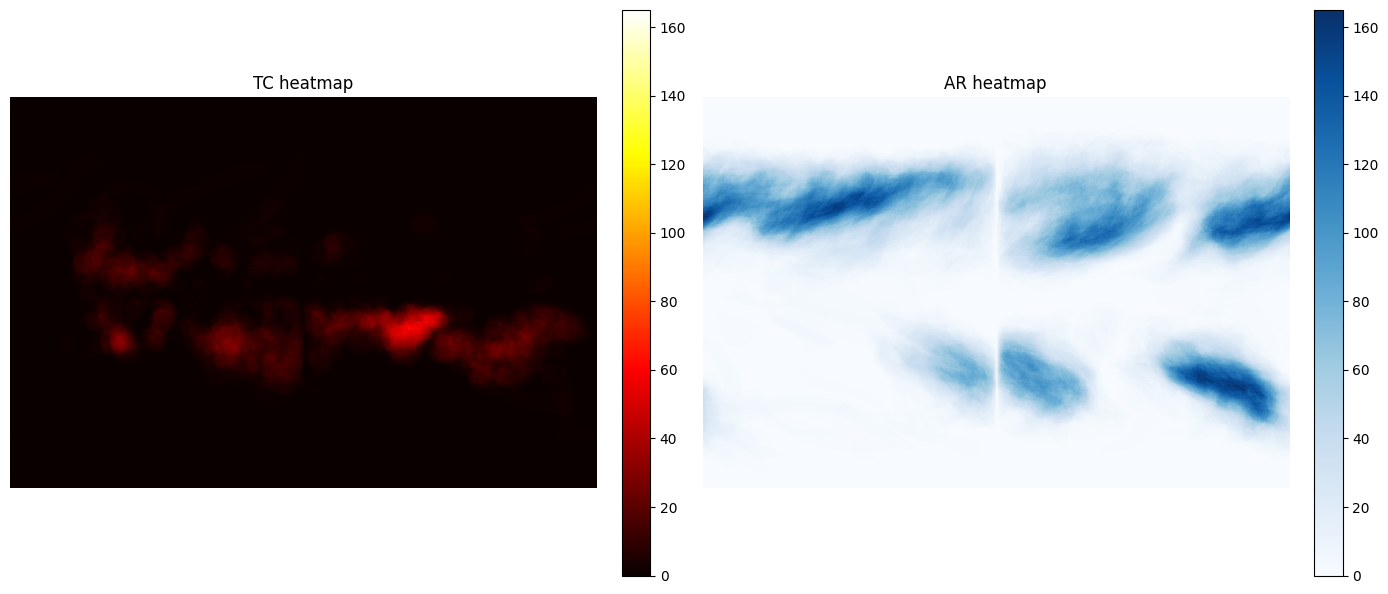

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Plot TC and AR heatmaps side-by-side (uses existing `heatmaps` and `plt` from the notebook)
hm_tc = heatmaps['tc']
hm_ar = heatmaps['ar']

# ensure 2D numpy arrays
hm_tc = np.asarray(hm_tc)
hm_ar = np.asarray(hm_ar)

vmax = max(hm_tc.max(), hm_ar.max()) if (hm_tc.size and hm_ar.size) else None

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(hm_tc, cmap='hot', vmin=0, vmax=vmax, origin='upper', interpolation='nearest')
axes[0].set_title('TC heatmap')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(hm_ar, cmap='Blues', vmin=0, vmax=vmax, origin='upper', interpolation='nearest')
axes[1].set_title('AR heatmap')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [5]:
extremes_dict = train_dataset.get_hemisphere_extremal_points()

Scanning 398 files for extremal points...


KeyboardInterrupt: 

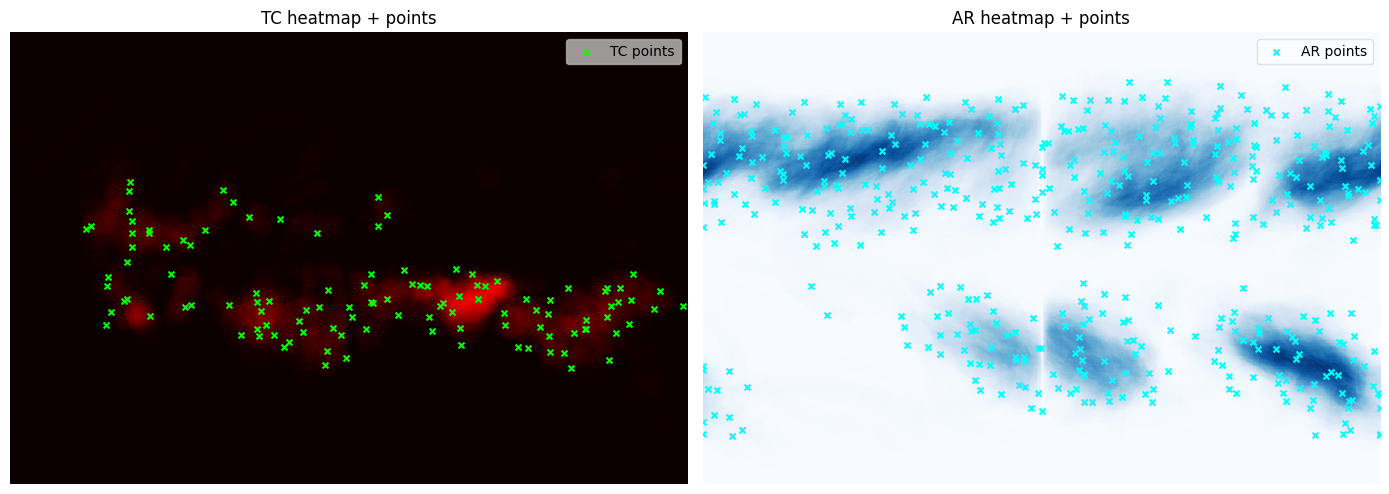

In [8]:
# For Tropical Cyclones
tc_points, tc_labels = train_dataset.generate_smart_grid_prompts(
    class_type='tc', 
    grid_size=(32, 32),    # Base density
    jitter_amount=0.8,     # High randomness for training
    min_occurrences=5      # Ignore pixels where TCs occurred fewer than 5 times
)

# For Atmospheric Rivers
ar_points, ar_labels = train_dataset.generate_smart_grid_prompts(
    class_type='ar', 
    grid_size=(32, 32), 
    jitter_amount=0.8,
    min_occurrences=5
)

# overlay tc_points and ar_points on the respective heatmaps
tc_pts = tc_points.detach().cpu().numpy().reshape(-1, 2)
ar_pts = ar_points.detach().cpu().numpy().reshape(-1, 2)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].imshow(hm_tc, cmap='hot', origin='upper', interpolation='nearest', vmin=0, vmax=vmax)
axs[0].scatter(tc_pts[:, 0], tc_pts[:, 1], c='lime', s=18, marker='x', linewidths=1.5, label='TC points')
axs[0].set_title('TC heatmap + points')
axs[0].axis('off')
axs[0].legend(loc='upper right', framealpha=0.6)

axs[1].imshow(hm_ar, cmap='Blues', origin='upper', interpolation='nearest', vmin=0, vmax=vmax)
axs[1].scatter(ar_pts[:, 0], ar_pts[:, 1], c='cyan', s=18, marker='x', linewidths=1.5, label='AR points')
axs[1].set_title('AR heatmap + points')
axs[1].axis('off')
axs[1].legend(loc='upper right', framealpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
tc_points

tensor([[[ 199.5646,  247.8034]],

        [[ 191.3669,  276.0441]],

        [[ 377.0372,  283.6853]],

        [[ 646.5977,  252.7012]],

        [[ 164.6284,  280.8598]],

        [[ 386.2470,  286.0269]],

        [[ 611.4796,  279.7934]],

        [[ 152.4418,  332.7762]],

        [[ 207.6312,  313.6670]],

        [[ 229.5032,  321.0045]],

        [[ 260.3982,  305.9520]],

        [[ 320.0039,  303.9979]],

        [[ 403.0382,  314.9471]],

        [[ 461.7354,  322.3168]],

        [[ 516.3224,  339.5258]],

        [[ 625.7205,  333.3710]],

        [[ 156.8904,  349.6736]],

        [[ 199.4146,  351.8086]],

        [[ 201.3371,  344.2187]],

        [[ 250.8339,  348.1656]],

        [[ 268.5602,  331.4568]],

        [[ 209.2835,  384.1828]],

        [[ 297.3439,  390.1098]],

        [[ 210.4967,  436.8788]],

        [[ 280.0269,  410.9230]],

        [[ 592.0725,  401.8076]],

        [[ 642.2587,  405.6605]],

        [[ 699.5270,  413.0055]],

        [[ 769.9937,

In [ ]:
data.generate_smart_grid_prompts()

In [ ]:
{'tc': {'north': {'top': {'pixel': (105, 574),
    'latlon': (-65.35853976531942, 179.375),
    'file': 'data-2000-01-06-01-1_2.nc'},
   'bottom': {'pixel': (383, 452),
    'latlon': (-0.11734028683180889, 141.25),
    'file': 'data-1998-08-23-01-1_2.nc'}},
  'south': {'top': {'pixel': (384, 463),
    'latlon': (0.11734028683181563, 144.6875),
    'file': 'data-1998-08-23-01-1_2.nc'},
   'bottom': {'pixel': (678, 1097),
    'latlon': (69.11342894393742, 342.8125),
    'file': 'data-2002-02-04-01-1_0.nc'}}},
 'ar': {'north': {'top': {'pixel': (54, 851),
    'latlon': (-77.32724902216428, 265.9375),
    'file': 'data-2010-10-19-01-1_0.nc'},
   'bottom': {'pixel': (383, 68),
    'latlon': (-0.11734028683180889, 21.25),
    'file': 'data-1996-09-26-01-1_0.nc'}},
  'south': {'top': {'pixel': (384, 68),
    'latlon': (0.11734028683181563, 21.25),
    'file': 'data-1996-09-26-01-1_0.nc'},
   'bottom': {'pixel': (739, 103),
    'latlon': (83.42894393741852, 32.1875),

In [7]:
from utility import plot_mask_with_points_and_bbox
from utility import batch_to_cuda

most_top_point_tc_north = None
most_bottom_point_tc_north = None
most_top_point_ar_northh = None
most_bottom_point_ar_north = None


most_top_point_ar_south = None
most_bottom_point_ar_south = None
most_top_point_tc_south = None
most_bottom_point_tc_south = None

for batch in train_dataloader:
    batch = batch_to_cuda(batch, device)

    # compute vertical span magnitude per image in the batch for TC (1) and AR (2)
    masks = batch['gt_mask']
    # normalize shape to (B, H, W)
    B = len(masks)
    H, W = masks[0].shape
    half_row = H // 2

    # iterate images in batch and update global extremal points
    for i in range(B):
        m = masks[i].detach().cpu().numpy().astype(np.int32)

        # find all points for each class
        for cls in (1, 2):  # 1=TC, 2=AR
            pts = np.argwhere(m == cls)  # rows (y), cols (x)
            if pts.size == 0:
                continue

            # north = top half (rows < half_row), south = bottom half (rows >= half_row)
            north_pts = pts[pts[:, 0] < half_row]
            south_pts = pts[pts[:, 0] >= half_row]

            # helper to pick a representative x for a given y (mean x at that y)
            def rep_point_at_y(pt_array, y_val):
                xs = pt_array[pt_array[:, 0] == y_val, 1]
                x_rep = int(xs.mean()) if xs.size else int(pt_array[0, 1])
                return (y_val, x_rep)

            # NORTH hemisphere updates
            if north_pts.size:
                y_top = int(north_pts[:, 0].min())
                y_bot = int(north_pts[:, 0].max())
                yt, xt = rep_point_at_y(north_pts, y_top)
                yb, xb = rep_point_at_y(north_pts, y_bot)

                if cls == 1:  # TC
                    # most top (smallest y) in north
                    if (most_top_point_tc_north is None) or (yt < most_top_point_tc_north[1]):
                        most_top_point_tc_north = (i, yt, xt)
                    # most bottom (largest y) in north
                    if (most_bottom_point_tc_north is None) or (yb > most_bottom_point_tc_north[1]):
                        most_bottom_point_tc_north = (i, yb, xb)
                else:  # AR
                    if (most_top_point_ar_northh is None) or (yt < most_top_point_ar_northh[1]):
                        most_top_point_ar_northh = (i, yt, xt)
                    if (most_bottom_point_ar_north is None) or (yb > most_bottom_point_ar_north[1]):
                        most_bottom_point_ar_north = (i, yb, xb)

            # SOUTH hemisphere updates
            if south_pts.size:
                y_top_s = int(south_pts[:, 0].min())
                y_bot_s = int(south_pts[:, 0].max())
                yt_s, xt_s = rep_point_at_y(south_pts, y_top_s)
                yb_s, xb_s = rep_point_at_y(south_pts, y_bot_s)

                if cls == 1:  # TC
                    if (most_top_point_tc_south is None) or (yt_s < most_top_point_tc_south[1]):
                        most_top_point_tc_south = (i, yt_s, xt_s)
                    if (most_bottom_point_tc_south is None) or (yb_s > most_bottom_point_tc_south[1]):
                        most_bottom_point_tc_south = (i, yb_s, xb_s)
                else:  # AR
                    if (most_top_point_ar_south is None) or (yt_s < most_top_point_ar_south[1]):
                        most_top_point_ar_south = (i, yt_s, xt_s)
                    if (most_bottom_point_ar_south is None) or (yb_s > most_bottom_point_ar_south[1]):
                        most_bottom_point_ar_south = (i, yb_s, xb_s)

# Print summary of found points
print("most_top_point_tc_north:", most_top_point_tc_north)
print("most_bottom_point_tc_north:", most_bottom_point_tc_north)
print("most_top_point_ar_northh:", most_top_point_ar_northh)
print("most_bottom_point_ar_north:", most_bottom_point_ar_north)
print("most_top_point_ar_south:", most_top_point_ar_south)
print("most_bottom_point_ar_south:", most_bottom_point_ar_south)
print("most_top_point_tc_south:", most_top_point_tc_south)
print("most_bottom_point_tc_south:", most_bottom_point_tc_south)



most_top_point_tc_north: (1, 89, 471)
most_bottom_point_tc_north: (0, 383, 958)
most_top_point_ar_northh: (3, 39, 1065)
most_bottom_point_ar_north: (0, 383, 212)
most_top_point_ar_south: (0, 384, 212)
most_bottom_point_ar_south: (0, 739, 1048)
most_top_point_tc_south: (0, 384, 922)
most_bottom_point_tc_south: (2, 662, 577)


In [8]:
mask.shape

torch.Size([768, 1152])

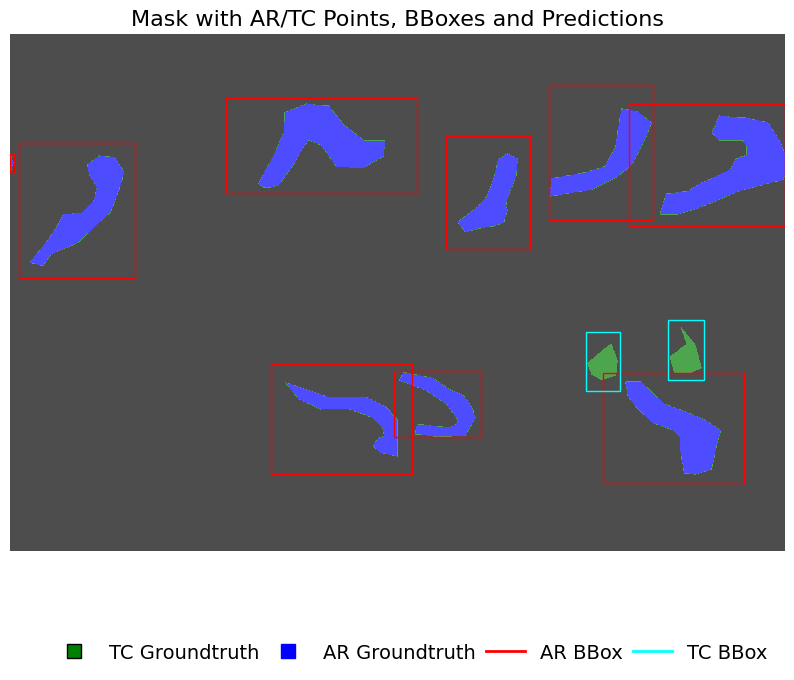

In [8]:
gt_mask = batch['gt_mask'][0].cpu().numpy()
bboxes_ar = batch['ar_bbox_prompts'][0].cpu().numpy()
bboxes_tc = batch['tc_bbox_prompts'][0].cpu().numpy()
plot_mask_with_points_and_bbox(gt_mask, ar_bbox= bboxes_ar, tc_bbox= bboxes_tc)


In [ ]:
# Get one gt
# Get ar_gt and tc_gt
# Get connected components
# get bbox and points and mask


In [ ]:
from utility import plot_mask_with_points_and_bbox
from utility import batch_to_cuda
for val_step, batch in enumerate(val_dataloader):
    batch = batch_to_cuda(batch, device)
    break

In [ ]:
import torch
import numpy as np
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt
import torch.nn.functional as F

def compute_centroid_heatmaps_old(gt_centroids_list, H, W, sigma=5.0, device=None ):
    """
    Build target gaussian heatmaps (B,1,H,W) from a list of centroid tensors (or None).
    Follows the same procedure as the provided compute_loss_centroid_heatmap but returns
    the heatmaps for visualization.
    """
    if device is None:
        device = torch.device('cpu')
    y_range = torch.arange(H, device=device).float()
    x_range = torch.arange(W, device=device).float()
    grid_y, grid_x = torch.meshgrid(y_range, x_range, indexing='ij')

    heatmaps = []
    for b, centroids in enumerate(gt_centroids_list):
        heatmap = torch.zeros((H, W), device=device)
        if centroids is not None and isinstance(centroids, torch.Tensor) and centroids.numel() > 0:
            # ensure centroids on the same device/float
            centroids = centroids.to(device).float()
            for i in range(centroids.shape[0]):
                cx, cy = centroids[i][0], centroids[i][1]  # centroids provided as (x, y)
                dist_sq = (grid_y - cy) ** 2 + (grid_x - cx) ** 2
                peak = torch.exp(-dist_sq / (2 * sigma ** 2))
                heatmap = torch.max(heatmap, peak)
        heatmaps.append(heatmap.unsqueeze(0))
    heatmaps = torch.stack(heatmaps, dim=0).unsqueeze(1)  # B,1,H,W
    return heatmaps

def compute_centroid_heatmaps(
    gt_centroids_list,
    H,
    W,
    sigma=10,
    device=None,
    radius=None,
    amplitude=1.0,
    normalize_coords=False,
    swap_xy=False,
    clamp=True,
):
    """
    Build target gaussian heatmaps (B,1,H,W) from a list of centroid tensors (or None).

    New parameters:
    - sigma: gaussian std (pixels)
    - radius: optional pixel cutoff radius (None = no cutoff). If set, values outside radius are zeroed.
    - amplitude: peak amplitude of each gaussian
    - normalize_coords: if True and centroids are in [0,1], scale to pixel coords
    - swap_xy: if True, interpret each centroid as (y,x) instead of (x,y)
    - clamp: clamp centroid coords to [0, W-1]/[0, H-1]
    """
    if device is None:
        device = torch.device('cpu')
    y_range = torch.arange(H, device=device).float()
    x_range = torch.arange(W, device=device).float()
    grid_y, grid_x = torch.meshgrid(y_range, x_range, indexing='ij')

    heatmaps = []
    for b, centroids in enumerate(gt_centroids_list):
        heatmap = torch.zeros((H, W), device=device)
        if centroids is not None and isinstance(centroids, torch.Tensor) and centroids.numel() > 0:
            centroids = centroids.to(device).float().clone()

            # auto-scale normalized coords if requested or detected
            if normalize_coords or (centroids.max() <= 1.0 and centroids.min() >= 0.0):
                centroids[:, 0] = centroids[:, 0] * (W - 1)  # x
                centroids[:, 1] = centroids[:, 1] * (H - 1)  # y

            if swap_xy:
                centroids = centroids[:, [1, 0]]

            if clamp:
                centroids[:, 0].clamp_(0, W - 1)
                centroids[:, 1].clamp_(0, H - 1)

            for i in range(centroids.shape[0]):
                cx, cy = centroids[i, 0], centroids[i, 1]  # (x, y)
                dist_sq = (grid_y - cy) ** 2 + (grid_x - cx) ** 2

                if radius is not None:
                    # mask out outside radius to limit influence / speed up
                    mask = (dist_sq <= (float(radius) ** 2)).float()
                else:
                    mask = 1.0

                peak = amplitude * torch.exp(-dist_sq / (2 * (float(sigma) ** 2)))
                peak = peak * mask
                heatmap = torch.max(heatmap, peak)
        heatmaps.append(heatmap.unsqueeze(0))
    heatmaps = torch.stack(heatmaps, dim=0).unsqueeze(1)  # B,1,H,W
    return heatmaps
# get spatial dims from batch (use gt_mask[0] which exists)
H, W = batch['gt_mask'][0].shape
tc_centroids = batch['ar_centroids']  # list length B, elements either Tensor or None

# compute heatmaps on the notebook device (use existing `device` if present)
_device = device if 'device' in globals() else torch.device('cpu')
heatmaps = compute_centroid_heatmaps(tc_centroids, H, W, sigma=8.0, device=_device)  # (B,1,H,W)

# Move to CPU / numpy for plotting
heatmaps_np = heatmaps.squeeze(1).detach().cpu().numpy()  # (B, H, W)

# Plot each batch element heatmap and overlay centroids (if any)
cmap = plt.get_cmap('hot')
for b in range(heatmaps_np.shape[0]):
    hm = heatmaps_np[b]
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(hm.squeeze(), cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'Batch item {b} - TC centroids: {0 if tc_centroids[b] is None else (tc_centroids[b].shape[0])}')
    ax.axis('off')
    # overlay centroids as red crosses if present
    if tc_centroids[b] is not None and isinstance(tc_centroids[b], torch.Tensor) and tc_centroids[b].numel() > 0:
        pts = tc_centroids[b].detach().cpu().numpy().reshape(-1, 2)
        xs = pts[:, 0]
        ys = pts[:, 1]
        # ax.scatter(xs, ys, marker='x', color='cyan',  s=60, linewidths=2)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, format="%.2f")
    plt.show()

In [ ]:
np.max(hm)

In [ ]:
hm

In [ ]:
i = 0
gt_mask = batch['gt_mask'][0]
tc_gt_mask = (batch['gt_mask'][0] == 1).to(torch.uint8).cpu().numpy()
ar_gt_mask = (batch['gt_mask'][0] == 2).to(torch.uint8).cpu().numpy()

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt

mask = gt_mask.cpu().numpy().astype(int)

cmap = ListedColormap(['black', 'green', 'blue'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask, cmap=cmap, norm=norm, interpolation='nearest', alpha=0.7)
ax.set_axis_off()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.margins(0)
ax.set_position([0, 0, 1, 1])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [ ]:
ar_k_req = 51
tc_k_req = 21
ar_sigma = 20
tc_sigma = 10

In [ ]:
import numpy as np
import cv2
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt

# get binary masks (prefer existing numpy arrays if available)
try:
    tc_bin = tc_gt_mask.astype(np.float32)
    ar_bin = ar_gt_mask.astype(np.float32)
except Exception:
    gm = gt_mask.detach().cpu().numpy().astype(np.int32)
    tc_bin = (gm == 1).astype(np.float32)
    ar_bin = (gm == 2).astype(np.float32)

# prepare categorical GT mask display
cmap = ListedColormap(['black', 'green', 'blue'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Original categorical mask (will be reused in all plots)
original_mask = (tc_bin + 2 * ar_bin).astype(int)

# Define configuration sets: (ar_kernel, ar_sigma, tc_kernel, tc_sigma)
configs = [
    (9, 2, 3, 1),    # Plot 1
    (21, 10, 11, 5),  # Plot 2
    (51, 10, 21, 10),  # Plot 3
]

# Plot 1: Original image only
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.imshow(original_mask, cmap=cmap, norm=norm, interpolation='nearest', alpha=0.8)
ax.set_title('GT mask')
ax.axis('off')
plt.tight_layout()
plt.show()

# Plots 2-4: Gaussian composite for each config (separate figures)
for plot_num, (ar_k_req, ar_s, tc_k_req, tc_s) in enumerate(configs, start=2):
    # Ensure kernel sizes are odd
    ar_k = ar_k_req if (ar_k_req % 2 == 1 and ar_k_req > 0) else ar_k_req + 1
    tc_k = tc_k_req if (tc_k_req % 2 == 1 and tc_k_req > 0) else tc_k_req + 1
    
    # Apply Gaussian blur
    ar_blur = cv2.GaussianBlur(ar_bin.astype(np.float32), (ar_k, ar_k), sigmaX=float(ar_s))
    tc_blur = cv2.GaussianBlur(tc_bin.astype(np.float32), (tc_k, tc_k), sigmaX=float(tc_s))
    
    # Normalize to [0,1]
    if ar_blur.max() > 0:
        ar_blur = ar_blur / float(ar_blur.max())
    if tc_blur.max() > 0:
        tc_blur = tc_blur / float(tc_blur.max())
    
    # RGB composite: background black, G = TC, B = AR
    rgb = np.zeros((ar_blur.shape[0], ar_blur.shape[1], 3), dtype=np.float32)
    rgb[..., 1] = tc_blur
    rgb[..., 2] = ar_blur
    rgb = np.clip(rgb, 0.0, 1.0)
    
    # Plot: Gaussian composite as separate figure
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.imshow(rgb, origin='upper', interpolation='nearest', alpha=0.8)
    ax.set_title(f'Gaussian Blur\n(AR k={ar_k}, σ={ar_s}; TC k={tc_k}, σ={tc_s})')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import numpy as np

# Build an RGB composite where:
# - background = black
# - G channel = TC gaussian (tc_mask_gaussian)
# - B channel = AR gaussian (ar_mask_gaussian)
# This shows both blurred maps in one image using black/green/blue as requested.

# Ensure numpy arrays (H, W) float32 in [0,1]
ar = np.asarray(ar_mask_gaussian, dtype=np.float32)
tc = np.asarray(tc_mask_gaussian, dtype=np.float32)

# Safety: if arrays have extra dims, squeeze
if ar.ndim > 2:
    ar = np.squeeze(ar)
if tc.ndim > 2:
    tc = np.squeeze(tc)

ar = np.clip(ar, 0.0, 1.0)
tc = np.clip(tc, 0.0, 1.0)

# Compose RGB: R=0, G=tc, B=ar
rgb = np.zeros((ar.shape[0], ar.shape[1], 3), dtype=np.float32)
rgb[..., 1] = tc  # green channel
rgb[..., 2] = ar  # blue channel
rgb = np.clip(rgb, 0.0, 1.0)

# Prepare discrete GT mask plotting (black, green, blue)
mask = gt_mask.cpu().numpy().astype(int)
cmap = ListedColormap(['black', 'green', 'blue'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Show side-by-side: left = composite gaussian overlays, right = categorical GT mask
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].imshow(rgb, origin='upper', interpolation='nearest')
axs[0].set_title('Gaussian overlays (G = TC, B = AR)')
axs[0].axis('off')

axs[1].imshow(mask, cmap=cmap, norm=norm, interpolation='nearest', alpha=0.8)
axs[1].set_title('Ground-truth categorical mask')
axs[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from utility import plot_mask_with_points_and_bbox_old, plot_mask_with_points_and_bbox
from IPython.display import display

mask_2 = batch['gt_mask'][1].cpu().numpy().astype(int)
fig = plot_mask_with_points_and_bbox_old(mask, ar_points=None, tc_points=None, ar_bbox=None, tc_bbox=None, 
                                    tc_pred_mask=None, ar_pred_mask=mask_2, radius=8, save_path='exp', axis=False, title = None)
fig_2 = plot_mask_with_points_and_bbox(mask, ar_points=None, tc_points=None, ar_bbox=None, tc_bbox=None,
                                    tc_pred_mask=None, ar_pred_mask=mask_2, radius=8, save_path='exp', axis=False, title=None)

# The utility functions return matplotlib.figure.Figure objects.
# Display the figures directly in the notebook instead of passing them to plt.imshow (which causes dtype object errors).
for f in [fig, fig_2]:
    try:
        display(f)
    except Exception:
        # Fallback: render the figure canvas to an image and show with plt.imshow
        import numpy as np
        canvas = f.canvas
        canvas.draw()
        img = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')
        w, h = canvas.get_width_height()
        img = img.reshape(h, w, 3)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

In [ ]:
# Plot ground-truth mask on a global PlateCarree projection (no legend).
# Shows latitude lines at 5, 30, 60 degrees (and their negatives) with labels.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import matplotlib.ticker as mticker
    has_cartopy = True
except Exception:
    has_cartopy = False

# Prepare mask arrays
gt_mask = batch['gt_mask'][3]
mask = gt_mask.cpu().numpy().astype(int)
# AR (value 2) and TC (value 1)
ar_gt = (mask == 2).astype(float)
tc_gt = (mask == 1).astype(float)

# Longitude / latitude axes assuming full-world extent
# Ensure lat is ascending (from -90 at bottom to 90 at top)
lon = np.linspace(-180, 180, mask.shape[1])
lat = np.linspace(90, -90, mask.shape[0])
Lon, Lat = np.meshgrid(lon, lat)

# Define latitudinal band masks (absolute latitudes)
band_eq = (np.abs(Lat) <= 5)
band_mid = ((np.abs(Lat) > 5) & (np.abs(Lat) <= 30))
band_high = ((np.abs(Lat) > 30) & (np.abs(Lat) <= 60))

# Desired tick latitudes; ensure sorted ascending
lat_ticks = sorted([-60, -30, -5, 5, 30, 60])
lon_ticks = [-180, -120, -60, 0, 60, 120, 180]

if has_cartopy:
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    # Background image: light land
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', zorder=1)

    # Contour-fill ground truth masks (no legend)
    ax.contourf(lon, lat, ar_gt, levels=[0.5, 1.0], colors=['blue'], alpha=0.7, transform=ccrs.PlateCarree(), zorder=2)
    ax.contourf(lon, lat, tc_gt, levels=[0.5, 1.0], colors=['green'], alpha=0.7, transform=ccrs.PlateCarree(), zorder=3)

    # Overlay latitudinal bands with very low opacity (5% = 0.05)
    ax.contourf(lon, lat, band_eq.astype(float), levels=[0.5, 1.0], colors=['red'], alpha=0.1, transform=ccrs.PlateCarree(), zorder=4)
    ax.contourf(lon, lat, band_mid.astype(float), levels=[0.5, 1.0], colors=['green'], alpha=0.1, transform=ccrs.PlateCarree(), zorder=5)
    ax.contourf(lon, lat, band_high.astype(float), levels=[0.5, 1.0], colors=['blue'], alpha=0.1, transform=ccrs.PlateCarree(), zorder=6)

    # Gridlines and labeled latitudes
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
    # show labels only on left for y
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = True

    # Set tick locators using sorted ascending latitudes
    gl.xlocator = mticker.FixedLocator(lon_ticks)
    gl.ylocator = mticker.FixedLocator(lat_ticks)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Remove any extra axes decorations where possible
    try:
        ax.outline_patch.set_visible(False)
    except Exception:
        pass

    # plt.title('Ground truth (global projection)')
    plt.show()
else:
    # Fallback: simple imshow with no projection
    cmap = ListedColormap(['black', 'green', 'blue'])
    fig, ax = plt.subplots(figsize=(10, 5))
    # Flip mask vertically so that latitude ordering is bottom->top when using origin='lower'
    display_mask = np.flipud(mask)
    ax.imshow(display_mask, cmap=cmap, interpolation='nearest', origin='lower', extent=[-180, 180, -90, 90])
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

    # Overlay latitudinal bands using axhspan (5% opacity)
    ax.axhspan(-5, 5, color='red', alpha=0.05, zorder=2)
    ax.axhspan(5, 30, color='yellow', alpha=0.05, zorder=2)
    ax.axhspan(-30, -5, color='yellow', alpha=0.05, zorder=2)
    ax.axhspan(30, 60, color='purple', alpha=0.05, zorder=2)
    ax.axhspan(-60, -30, color='purple', alpha=0.05, zorder=2)

    # Show horizontal lines at requested latitudes and label them
    for lt in lat_ticks:
        ax.axhline(lt, color='white', linestyle='--', linewidth=0.6)
        ax.text(-175, lt + 1.5, f'{lt}°', color='white', fontsize=9, va='center')

    ax.axis('off')
    plt.title('Ground truth (fallback, no projection)')
    plt.show()


In [ ]:
plt.figure(figsize=(5, 4))
plt.imshow(tc_gt_mask, cmap=ListedColormap(['black', 'green']), norm=norm, interpolation='nearest', alpha= 0.7)
plt.axis('off')
plt.show()

In [ ]:
ar_object_masks = batch['ar_object_masks'][0]

ar_object_masks.shape

In [ ]:
# plot each ar object mask in its own figure (one after another)
try:
    masks = ar_object_masks.cpu().numpy()
except Exception:
    masks = np.array(ar_object_masks)

# collapse channel dim if present: expected (N, 1, H, W) -> (N, H, W)
if masks.ndim == 4 and masks.shape[1] == 1:
    masks = masks[:, 0, ...]
elif masks.ndim == 4 and masks.shape[1] != 1:
    masks = masks.max(axis=1)
elif masks.ndim == 2:
    masks = masks[None, ...]

cmap_ar = ListedColormap(['black', 'blue'])

for i, m in enumerate(masks):
    m2 = (np.squeeze(m) > 0.5).astype(np.uint8)
    plt.figure(figsize=(5, 4))
    plt.imshow(m2, cmap=cmap_ar, interpolation='nearest', alpha=0.7)
    # plt.title(f"mask {i}", fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
# create one point prompt, one bbox prompt, and one mask prompt for batch['ar_object_masks'][0][0]

obj = batch['ar_object_masks'][0][0]  # tensor, may be (1,H,W) or (H,W) or (1,1,H,W)
m = obj.cpu().numpy()

# normalize possible channel dims -> (H, W)
if m.ndim == 4 and m.shape[1] == 1:
    m = m[0, 0, ...]
elif m.ndim == 3 and m.shape[0] == 1:
    m = m[0, ...]
elif m.ndim == 3 and m.shape[0] != 1:
    m = m.max(axis=0)

bin_mask = (m > 0.5).astype(np.uint8)
h, w = bin_mask.shape

ys, xs = np.where(bin_mask)
if ys.size == 0:
    # fallback to image center and full-image bbox when object is empty
    cx, cy = w // 2, h // 2
    x1, y1, x2, y2 = 0, 0, w - 1, h - 1
else:
    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())
    cy = int(round((y1 + y2) / 2.0))
    cx = int(round((x1 + x2) / 2.0))

# point prompt as (x, y)
ar_point_prompt = torch.tensor([[float(cx), float(cy)]], dtype=torch.float32, device=device)

# bbox prompt as [x1, y1, x2, y2] with same nesting as existing prompts
ar_bbox_prompt = torch.tensor([[[float(x1), float(y1), float(x2), float(y2)]]], dtype=torch.float32, device=device)

# mask prompt as binary mask tensor on the same device
ar_mask_prompt = torch.from_numpy(bin_mask).to(device)  # shape (H, W)

print("ar_point_prompt:", ar_point_prompt)
print("ar_bbox_prompt:", ar_bbox_prompt)
print("ar_mask_prompt.shape:", ar_mask_prompt.shape)

In [ ]:
# Show Gaussian blur results for requested kernel sizes (9x9, 15x15, 20x20).
# Uses existing notebook variables: obj, cv2, np, plt, torch

# prepare numpy array from obj (move to CPU if needed)
if isinstance(obj, torch.Tensor):
    arr = obj.detach().cpu().numpy()
else:
    arr = np.array(obj)

# collapse possible channel/batch dims -> (H, W)
if arr.ndim == 4:           # (N, C, H, W)
    arr = arr[0]
if arr.ndim == 3 and arr.shape[0] == 1:  # (1, H, W)
    arr = arr[0]
elif arr.ndim == 3 and arr.shape[0] != 1:  # (C, H, W)
    arr = arr.max(axis=0)

# ensure float32 in [0,1] for plotting/blur
arr = arr.astype(np.float32)
arr = np.clip(arr, 0.0, 1.0)

kernel_requests = [9, 71]  # user-requested sizes
blurred_list = []
applied_kernels = []
for k in kernel_requests:
    # OpenCV requires odd kernel sizes; if even, bump to next odd
    applied = k if (k % 2 == 1 and k > 0) else (k + 1)
    applied_kernels.append(applied)
    blurred = cv2.GaussianBlur(arr, (applied, applied), sigmaX=10)
    blurred_list.append(blurred)

# plot original + blurred variants side-by-side
n = len(blurred_list) + 1
fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
axes[0].imshow(arr, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original')
axes[0].axis('off')

for i, (k_req, k_applied, bimg) in enumerate(zip(kernel_requests, applied_kernels, blurred_list), start=1):
    axes[i].imshow(bimg, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'Requested {k_req}x{k_req}\nApplied {k_applied}x{k_applied}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Visualize the selected AR object mask in four variants (no legend / no grid):

1) Raw object mask
2) Mask with bounding box
3) Mask with point prompt
4) Noisy mask (uses make_noisy_mask_on_objects when available, otherwise a fallback)

In [ ]:

# 1) Raw object mask (no legend, no grid)
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import torch
import cv2
# from scipy.ndimage import binary_dilation
import cv2
# from scipy.ndimage import binary_dilation

# Derive a 2D binary mask from ar_mask_prompt (preferred) or fallback to obj

# try to get mask from ar_mask_prompt (preferred)
mask_np = ar_mask_prompt.detach().cpu().numpy()
object_mask = (mask_np > 0).astype(np.uint8)

# determine sensible dilation sizes (relative to image)
h_, w_ = object_mask.shape
dilate_size = max(5, int(min(h_, w_) * 0.01))  # ~1% of min dimension, at least 3
dilate_size_big = max(1, int(dilate_size * 1.5))

# perform dilation (cv2 if available, otherwise scipy fallback)

kernel_small = np.ones((dilate_size, dilate_size), np.uint8)
kernel_big = np.ones((dilate_size_big, dilate_size_big), np.uint8)
dilated_mask_small = cv2.dilate(object_mask.astype(np.uint8), kernel_small, iterations=1)
dilated_mask_big = cv2.dilate(object_mask.astype(np.uint8), kernel_big, iterations=1)


# annulus (negative region) between big and small dilations
negative_region = (dilated_mask_big - dilated_mask_small).clip(0, 1).astype(np.uint8)
region_points = np.argwhere(negative_region)

# Plot each separately
cmap_plot = ListedColormap(['black', 'blue'])
plt.figure(figsize=(5, 4))
plt.imshow(object_mask, cmap=cmap_plot, interpolation='nearest', alpha=0.7)
# plt.title('Original binary mask')
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(dilated_mask_small, cmap=cmap_plot, interpolation='nearest', alpha=0.7)
# plt.title(f'Dilated (small) - kernel {dilate_size}x{dilate_size}')
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(dilated_mask_big, cmap=cmap_plot, interpolation='nearest', alpha=0.7)
# plt.title(f'Dilated (big) - kernel {dilate_size_big}x{dilate_size_big}')
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(negative_region, cmap=ListedColormap(['black', 'red']), interpolation='nearest', alpha=0.7)
# overlay region points small and cheap (if many points this is light)
if region_points.size:
    ys, xs = region_points[:, 0], region_points[:, 1]
    plt.scatter(xs, ys, s=0.5, c='yellow', alpha=0.8)
# plt.title('Negative region (annulus: big - small)')
plt.axis('off')
plt.show()

# Eroded mask (no legend, no grid)
erode_size = dilate_size*2 # reuse previously computed sensible size
kernel_erode = np.ones((erode_size, erode_size), np.uint8)
eroded_mask = cv2.erode(object_mask.astype(np.uint8), kernel_erode, iterations=1)

plt.figure(figsize=(5, 4))
plt.imshow(eroded_mask, cmap=ListedColormap(['black', 'green']), interpolation='nearest', alpha=0.7)

plt.axis('off')
plt.show()

In [ ]:
    mask_np = ar_mask_prompt.detach().cpu().numpy()


In [ ]:
# 2) Mask with bounding box (no legend, no grid)
import matplotlib.patches as patches
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask_np, cmap=cmap_ar, interpolation='nearest', alpha=0.7)

# Try to extract bbox from ar_bbox_prompt
try:
    bbox_arr = ar_bbox_prompt.detach().cpu().numpy().reshape(-1, 4)
    x1, y1, x2, y2 = map(float, bbox_arr[0])
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none', )
    ax.add_patch(rect)
except Exception:
    # no bbox available; nothing to add
    pass

ax.axis('off')
plt.show()

In [ ]:
#  3) Mask with point prompt (no legend, no grid)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask_np, cmap=cmap_ar, interpolation='nearest', alpha=0.7)

# Try to extract the point from ar_point_prompt
try:
    pts = ar_point_prompt.detach().cpu().numpy().reshape(-1, 2)
    px, py = pts[0]
    # plot as red 'x'
    ax.scatter(px, py, marker='x', color='red', s=120, linewidths=2)
except Exception:
    pass

ax.axis('off')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

def make_noisy_mask_on_objects(object_masks, scale_factor: int = 8, noisy_mask_threshold: float = 0.5, h = 256, w = 256):
    """
        Add noise to mask input
        From Mask Transfiner https://github.com/SysCV/transfiner
    """
    def get_incoherent_mask(input_masks, h, w):
        mask = input_masks.float()
        h, w = input_masks.shape[-2:]

        mask_small = F.interpolate(mask, (h // scale_factor, w // scale_factor), mode='bilinear')
        mask_recover = F.interpolate(mask_small, (h, w), mode='bilinear')
        mask_residue = (mask - mask_recover).abs()
        mask_residue = (mask_residue >= 0.01).float()
        return mask_residue
    
    if object_masks.dim() == 3:
        object_masks = object_masks.unsqueeze(1)

    o_m_resized = F.interpolate(object_masks.float(), (h, w), mode='bilinear')
    mask_noise = torch.randn(o_m_resized.shape) * 1.0
    inc_masks = get_incoherent_mask(o_m_resized, h, w)
    o_m_noisy = ((o_m_resized + mask_noise * inc_masks) > noisy_mask_threshold).float()
    
    return o_m_noisy

In [ ]:
# noisy mask visualization (use make_noisy_mask_on_objects if available)
from matplotlib.colors import ListedColormap
import torch
import numpy as np
import torch.nn.functional as F

# Prepare object tensor with shape (N,1,H,W)
obj_t = obj
if isinstance(obj_t, np.ndarray):
    obj_t = torch.from_numpy(obj_t)
obj_t = obj_t.float()
if obj_t.dim() == 2:
    obj_t = obj_t.unsqueeze(0).unsqueeze(0)
elif obj_t.dim() == 3:
    # if (1,H,W) -> add batch dim; if (N,H,W) -> add channel dim
    if obj_t.shape[0] == 1:
        obj_t = obj_t.unsqueeze(0)
    else:
        obj_t = obj_t.unsqueeze(1)
elif obj_t.dim() == 4 and obj_t.shape[1] != 1:
    obj_t = obj_t.max(dim=1, keepdim=True)[0]

# Ensure mask_np is defined
if 'mask_np' not in globals():
    try:
        mask_np = ar_mask_prompt.detach().cpu().numpy()
    except Exception:
        tmp = obj.detach().cpu().numpy() if isinstance(obj, torch.Tensor) else np.array(obj)
        if tmp.ndim == 4 and tmp.shape[1] == 1:
            tmp = tmp[0, 0, ...]
        elif tmp.ndim == 3 and tmp.shape[0] == 1:
            tmp = tmp[0, ...]
        elif tmp.ndim == 3 and tmp.shape[0] != 1:
            tmp = tmp.max(axis=0)
        mask_np = (tmp > 0.5).astype(np.uint8)

# Attempt to use the utility function; run on CPU to avoid device mismatch inside function
try:
    from dataset.climatenet_util import make_noisy_mask_on_objects
    noisy = make_noisy_mask_on_objects(obj_t.cpu(), h=mask_np.shape[0], w=mask_np.shape[1])
    noisy_np = noisy.squeeze().cpu().numpy()
except Exception as e:
    # fallback: resize and add gaussian noise (operate on CPU)
    try:
        o = F.interpolate(obj_t.cpu(), size=mask_np.shape, mode='bilinear')
        noise = torch.randn_like(o) * 0.8
        noisy_tensor = ((o + noise) > 0.5).float()
        noisy_np = noisy_tensor.squeeze().cpu().numpy()
    except Exception as e2:
        print('Failed to compute noisy mask:', e, e2)
        noisy_np = mask_np.copy()

cmap_noisy = ListedColormap(['black', 'blue'])
plt.figure(figsize=(5, 4))
plt.imshow(noisy_np, cmap=ListedColormap(['black', 'red']), interpolation='nearest', alpha=0.7)
plt.axis('off')
plt.show()


In [ ]:
# Show each intermediate as its own figure (one figure per intermediate image per object)
# Uses variables already computed in the notebook (o_m_noisy_np, o_m_resized_np, mask_small_np, ...)
for i in range(display_n):
    small = mask_small_np[i]
    small_up = cv2.resize((small * 255).astype(np.uint8), (w_out, h_out), interpolation=cv2.INTER_NEAREST) / 255.0

    imgs = [
        orig_objs_np[i],
        small,
        small_up,
        mask_recover_np[i],
        residue_cont_np[i],
        residue_bin_np[i],
        mask_noise_np[i],
        applied_noise_np[i],
        o_m_noisy_np[i],
    ]
    titles = [
        "Original object (binary)",
        f"Resized small (down {scale_factor}x)",
        "Resized small (upsampled back)",
        "Recover (resized -> small -> back)",
        "Residue (continuous)",
        "Residue (binary)",
        "Mask noise (gaussian)",
        "Applied noise (noise * residue_bin)",
        "Final noisy mask",
    ]

    for title, img in zip(titles, imgs):
        plt.figure(figsize=(5, 4))
        # Let matplotlib auto-scale for continuous/noisy images; masks look fine with gray colormap.
        plt.imshow(img, cmap=ListedColormap(['black', 'yellow']), interpolation='nearest', alpha=0.7)
        # plt.title(f'Obj {i}: {title}')
        plt.axis('off')
        plt.show()


In [ ]:
obj_t.squeeze().shape

Scanning train: 100%|██████████| 398/398 [00:25<00:00, 15.66it/s]
Scanning train: 100%|██████████| 398/398 [00:25<00:00, 15.66it/s]
Scanning test: 100%|██████████| 61/61 [00:04<00:00, 14.52it/s]
--- Train ---
Number of samples: 398
Average TC objects per sample: 2.570 (median 2.0)
Average AR objects per sample: 7.706 (median 8.0)
Samples with no TC labels: 67 / 398
Class pixel counts:
  class 0: 330520699 (freq 0.938646)
  class 1: 1626347 (freq 0.004619)
  class 2: 19977882 (freq 0.056735)
Mean TC pixels per image: 4086.3 (median 3425.0)
Mean AR pixels per image: 50195.7 (median 49199.0)


--- Val ---
Number of samples: 61
Average TC objects per sample: 2.934 (median 2.0)
Average AR objects per sample: 6.967 (median 7.0)
Samples with no TC labels: 14 / 61
Class pixel counts:
  class 0: 50654302 (freq 0.938583)
  class 1: 296594 (freq 0.005496)
  class 2: 3018000 (freq 0.055921)
Mean TC pixels per image: 4862.2 (median 3006.0)
Mean AR pixels per image: 49475.4 (median 47352.0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# dataset/class statistics extracted from the scanning output
classes = ['background', 'TC', 'AR']

train = {
    'num_samples': 398,
    'avg_tc': 2.570,
    'median_tc': 2.0,
    'avg_ar': 7.706,
    'median_ar': 8.0,
    'no_tc_samples': 67,
    'class_counts': [330520699, 1626347, 19977882],
    'class_freqs': [330520699, 1626347, 19977882],  # raw counts (pie will compute percentages)
    'mean_tc_pixels': 4086.3,
    'median_tc_pixels': 3425.0,
    'mean_ar_pixels': 50195.7,
    'median_ar_pixels': 49199.0,
}

val = {
    'num_samples': 61,
    'avg_tc': 2.934,
    'median_tc': 2.0,
    'avg_ar': 6.967,
    'median_ar': 7.0,
    'no_tc_samples': 14,
    'class_counts': [50654302, 296594, 3018000],
    'class_freqs': [50654302, 296594, 3018000],
    'mean_tc_pixels': 4862.2,
    'median_tc_pixels': 3006.0,
    'mean_ar_pixels': 49475.4,
    'median_ar_pixels': 47352.0,
}

In [ ]:

# enforce requested colors: gray background, green TC, blue AR
colors_classes = ["#b0a4a4", "#4bff51", "#004882"]  # background, TC, AR
tc_color = colors_classes[1]
ar_color = colors_classes[2]
bg_color = colors_classes[0]

# 1) Average object counts (TC / AR) - separate figure
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
labels = ['TC objects', 'AR objects']
train_vals = [train['avg_tc'], train['avg_ar']]
val_vals = [val['avg_tc'], val['avg_ar']]
x = np.arange(len(labels))
width = 0.35
off = width / 4
ax.bar(x - off, train_vals, width/2, label='Train', color=[tc_color, ar_color], alpha=0.9)
ax.bar(x + off, val_vals, width/2, label='Val', color=[tc_color, ar_color], alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Average objects per sample')
ax.set_title('Average TC / AR objects per sample')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:


# 2) Samples counts and no-TC summary (text) - separate figure
fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(1, 1, 1)
ax.axis('off')
txt = (
    f"Train samples: {train['num_samples']}\n"
    f"Train samples w/o TC: {train['no_tc_samples']} ({train['no_tc_samples']/train['num_samples']:.1%})\n\n"
    f"Val samples:   {val['num_samples']}\n"
    f"Val samples w/o TC: {val['no_tc_samples']} ({val['no_tc_samples']/val['num_samples']:.1%})"
)
ax.text(0, 0.5, txt, fontsize=12, va='center')
plt.tight_layout()
plt.show()

# 3) Class pixel frequency pie chart (Train) - Updated


# 3) Class pixel frequency pie chart (Train) - Legend Style
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate total for percentages or use raw freqs
total = sum(train['class_freqs'])
legend_labels = [f'{c}: {v/total*100:.2f}%' for c, v in zip(classes, train['class_freqs'])]

wedges, texts = ax.pie(
    train['class_freqs'],
    colors=colors_classes,
    startangle=90,
    textprops={'fontsize': 12}
)

# Add the legend with the formatted labels
ax.legend(
    wedges, 
    legend_labels,
    title="Classes",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

ax.set_title('Train: class pixel frequency', fontsize=14)
plt.tight_layout()
plt.show()
# Style adjustments
for t in texts:
    t.set_fontsize(12)
for t in autotexts:
    t.set_fontsize(12) # Slightly smaller font often looks better when outside
    t.set_color('black') # Ensure they are visible against the background

ax.set_title('Train: class pixel frequency', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 4) Class pixel frequency pie chart (Val) - separate figure
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)
wedges, texts, autotexts = ax.pie(
    val['class_freqs'],
    labels=classes,
    autopct='%1.2f%%',
    colors=colors_classes,
    startangle=90
)
for t in texts:
    t.set_fontsize(12)
for t in autotexts:
    t.set_fontsize(14)
ax.set_title('Val: class pixel frequency', fontsize=14)
plt.tight_layout()
plt.show()

# 5) Mean pixels per image (TC and AR) - separate figure
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
labels2 = ['Mean TC pixels', 'Mean AR pixels']
train_pix = [train['mean_tc_pixels'], train['mean_ar_pixels']]
val_pix = [val['mean_tc_pixels'], val['mean_ar_pixels']]
x2 = np.arange(len(labels2))
ax.bar(x2 - off, train_pix, width/2, label='Train', color=[tc_color, ar_color], alpha=0.9)
ax.bar(x2 + off, val_pix, width/2, label='Val', color=[tc_color, ar_color], alpha=0.4)
ax.set_xticks(x2)
ax.set_xticklabels(labels2)
ax.set_ylabel('Pixels')
ax.set_title('Mean pixels per image (TC / AR)')
ax.legend()
plt.tight_layout()
plt.show()

# 6) Absolute class pixel counts (log scale) for train vs val - separate figure
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)
x3 = np.arange(len(classes))
train_counts = train['class_counts']
val_counts = val['class_counts']
# use class colors for both train/val, differentiate by alpha
class_colors_list = [bg_color, tc_color, ar_color]
ax.bar(x3 - off, train_counts, width/2, label='Train', color=class_colors_list, alpha=0.9)
ax.bar(x3 + off, val_counts, width/2, label='Val', color=class_colors_list, alpha=0.4)
ax.set_xticks(x3)
ax.set_xticklabels(classes)
ax.set_yscale('log')
ax.set_ylabel('Pixel counts (log scale)')
ax.set_title('Absolute class pixel counts (log scale)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
classes = ['Background', 'Tropical Cyclone ', 'Atmospheric river']
# Reduce the figure width from 10 to 7 to force them together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4))

# 1. Calculate totals and percentages
total_train = sum(train['class_freqs'])
total_val = sum(val['class_freqs'])

train_pcts = [v/total_train*100 for v in train['class_freqs']]
val_pcts = [v/total_val*100 for v in val['class_freqs']]

# 2. Combined labels
combined_labels = [
    f'{c}\nT: {t:.1f}%, V: {v:.1f}%' 
    for c, t, v in zip(classes, train_pcts, val_pcts)
]

# 3. Train Pie
wedges, _ = ax1.pie(
    train['class_freqs'],
    colors=colors_classes,
    startangle=90,
    radius=0.9 # Slightly larger radius helps them look closer
)
ax1.set_xlabel('Train', fontsize=14, fontweight='bold', labelpad=-10)

# 4. Val Pie
ax2.pie(
    val['class_freqs'],
    colors=colors_classes,
    startangle=90,
    radius=0.9
)
ax2.set_xlabel('Val', fontsize=14, fontweight='bold', labelpad=-10)

# 5. Legend - Moved closer to the charts (anchor 0.8)
fig.legend(
    wedges, 
    combined_labels, 
    title="Class Distribution",
    title_fontsize=18, 
    loc="center left", 
    bbox_to_anchor=(0.8, 0.5), 
    fontsize=12,
    frameon=False
)

# 6. Negative wspace can actually overlap them if you want them "touching"
plt.subplots_adjust(wspace=-0.1, left=0.0, right=0.75, bottom=0.1)

# Save as transparent PNG
plt.savefig('ultra_compact_distribution.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()